In [1]:
print("ram ram")

ram ram


In [2]:
import os
import base64
import psycopg2
from typing import TypedDict, Annotated, Sequence
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, ToolMessage
from litellm import completion
from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv
load_dotenv()

# Keys Setup
os.environ["GEMINI_API_KEY"] = os.getenv("GEMINI_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

CONSTRUCTION_DB_URL=os.getenv("CONSTRUCTION_DB_URL")
MANUFACTURING_DB_URL=os.getenv("MANUFACTURING_DB_URL")


In [3]:
import json
from datetime import datetime, timedelta
from typing import Optional, List
from langchain_core.tools import tool
import psycopg2
from psycopg2.extras import RealDictCursor

# -------------------------------------------------
# Helper
# -------------------------------------------------
def _run_query(db_url: str, query: str, params: tuple = None) -> str:
    """Execute a query and return clean JSON-serializable results."""
    try:
        conn = psycopg2.connect(db_url)
        cursor = conn.cursor(cursor_factory=RealDictCursor)
        cursor.execute(query, params or ())
        rows = cursor.fetchall()
        cursor.close()
        conn.close()
        # Convert datetime objects etc. to strings
        clean = []
        for row in rows:
            clean.append({k: (v.isoformat() if hasattr(v, "isoformat") else v) for k, v in dict(row).items()})
        return json.dumps(clean, default=str, indent=2)
    except Exception as e:
        return f"ERROR: {str(e)}"


# =================================================
#  SAFETY / INCIDENTS / HSE TOOLS
# =================================================

@tool
def get_incidents(
    days: int = 7,
    is_active: Optional[bool] = None,
    is_acknowledged: Optional[bool] = None,
    camera_id: Optional[int] = None,
    class_name: Optional[str] = None,
    limit: int = 50
) -> str:
    """Fetch safety incidents. Filter by last N days, active status, acknowledged status, camera, or class name (e.g. 'no_helmet', 'fall')."""
    conditions = ["started_at >= NOW() - INTERVAL '%s days'" % days]
    params = []
    if is_active is not None:
        conditions.append("is_active = %s")
        params.append(is_active)
    if is_acknowledged is not None:
        conditions.append("is_acknowledged = %s")
        params.append(is_acknowledged)
    if camera_id:
        conditions.append("camera_id = %s")
        params.append(camera_id)
    if class_name:
        conditions.append("class_name ILIKE %s")
        params.append(f"%{class_name}%")
    
    query = f"""
        SELECT id, camera_id, camera_name, zone_id, track_id, class_name, confidence,
               is_active, is_acknowledged, is_recurring, classification, escalation_status,
               started_at, resolved_at, duration_seconds, snapshot_path
        FROM incidents
        WHERE {' AND '.join(conditions)}
        ORDER BY started_at DESC
        LIMIT %s
    """
    params.append(limit)
    return _run_query(CONSTRUCTION_DB_URL, query, tuple(params))


@tool
def get_alerts(
    days: int = 7,
    is_acknowledged: Optional[bool] = None,
    camera_id: Optional[int] = None,
    class_name: Optional[str] = None,
    limit: int = 50
) -> str:
    """Fetch recent alerts generated by AI detection rules."""
    conditions = ["created_at >= NOW() - INTERVAL '%s days'" % days]
    params = []
    if is_acknowledged is not None:
        conditions.append("is_acknowledged = %s")
        params.append(is_acknowledged)
    if camera_id:
        conditions.append("camera_id = %s")
        params.append(camera_id)
    if class_name:
        conditions.append("class_name ILIKE %s")
        params.append(f"%{class_name}%")

    query = f"""
        SELECT id, camera_id, camera_name, zone_id, track_id, class_name, confidence,
               is_acknowledged, created_at, snapshot_path
        FROM alerts
        WHERE {' AND '.join(conditions)}
        ORDER BY created_at DESC
        LIMIT %s
    """
    params.append(limit)
    return _run_query(CONSTRUCTION_DB_URL, query, tuple(params))


@tool
def get_hse_rule_events(
    days: int = 7,
    severity: Optional[str] = None,
    camera_id: Optional[int] = None,
    limit: int = 50
) -> str:
    """Fetch HSE (Health Safety Environment) rule violation events."""
    conditions = ["triggered_at >= NOW() - INTERVAL '%s days'" % days]
    params = []
    if severity:
        conditions.append("severity ILIKE %s")
        params.append(f"%{severity}%")
    if camera_id:
        conditions.append("camera_id = %s")
        params.append(camera_id)

    query = f"""
        SELECT id, camera_id, rule_id, track_id, triggered_at, severity, snapshot_path, detail
        FROM hse_rule_events
        WHERE {' AND '.join(conditions)}
        ORDER BY triggered_at DESC
        LIMIT %s
    """
    params.append(limit)
    return _run_query(CONSTRUCTION_DB_URL, query, tuple(params))


@tool
def get_anomaly_flags(
    days: int = 7,
    severity: Optional[str] = None,
    is_acknowledged: Optional[bool] = None,
    limit: int = 30
) -> str:
    """Fetch anomaly flags (unusual patterns detected by the system)."""
    conditions = ["created_at >= NOW() - INTERVAL '%s days'" % days]
    params = []
    if severity:
        conditions.append("severity ILIKE %s")
        params.append(f"%{severity}%")
    if is_acknowledged is not None:
        conditions.append("is_acknowledged = %s")
        params.append(is_acknowledged)

    query = f"""
        SELECT id, anomaly_type, severity, description, zone_id, camera_id, class_name,
               baseline_value, observed_value, deviation_factor, event_count, window_hours,
               is_acknowledged, created_at
        FROM anomaly_flags
        WHERE {' AND '.join(conditions)}
        ORDER BY created_at DESC
        LIMIT %s
    """
    params.append(limit)
    return _run_query(CONSTRUCTION_DB_URL, query, tuple(params))


@tool
def get_correlated_events(days: int = 7, limit: int = 20) -> str:
    """Fetch correlated multi-class events with risk scores (higher level safety insights)."""
    query = """
        SELECT id, camera_id, zone_id, classes, alert_ids, risk_score, window_minutes, narrative, created_at
        FROM correlated_events
        WHERE created_at >= NOW() - INTERVAL '%s days'
        ORDER BY risk_score DESC NULLS LAST, created_at DESC
        LIMIT %s
    """ % (days, limit)
    return _run_query(CONSTRUCTION_DB_URL, query)


@tool
def get_zone_risk_scores(limit: int = 30) -> str:
    """Get current zone risk scores across the site."""
    query = """
        SELECT zrs.id, zrs.zone_id, z.name as zone_name, zrs.camera_id, c.name as camera_name,
               zrs.risk_score, zrs.updated_at
        FROM zone_risk_scores zrs
        LEFT JOIN zones z ON z.id = zrs.zone_id
        LEFT JOIN cameras c ON c.id = zrs.camera_id
        ORDER BY zrs.risk_score DESC NULLS LAST
        LIMIT %s
    """
    return _run_query(CONSTRUCTION_DB_URL, query, (limit,))


@tool
def get_agent_recommendations(
    days: int = 14,
    priority: Optional[str] = None,
    is_acknowledged: Optional[bool] = None,
    limit: int = 30
) -> str:
    """Fetch AI agent recommendations (suggested actions for supervisors)."""
    conditions = ["created_at >= NOW() - INTERVAL '%s days'" % days]
    params = []
    if priority:
        conditions.append("priority ILIKE %s")
        params.append(f"%{priority}%")
    if is_acknowledged is not None:
        conditions.append("is_acknowledged = %s")
        params.append(is_acknowledged)

    query = f"""
        SELECT id, agent_id, category, priority, title, description, zone_id, camera_id,
               is_acknowledged, is_dismissed, created_at
        FROM agent_recommendations
        WHERE {' AND '.join(conditions)}
        ORDER BY created_at DESC
        LIMIT %s
    """
    params.append(limit)
    return _run_query(CONSTRUCTION_DB_URL, query, tuple(params))


# =================================================
#  CAMERAS / ZONES / DETECTION
# =================================================

@tool
def get_cameras(
    status: Optional[str] = None,
    plant_id: Optional[int] = None,
    department_id: Optional[int] = None,
    use_for_face_recognition: Optional[bool] = None
) -> str:
    """List all cameras with optional filters for status, plant, department, or face-recognition usage."""
    conditions = ["1=1"]
    params = []
    if status:
        conditions.append("status ILIKE %s")
        params.append(f"%{status}%")
    if plant_id:
        conditions.append("plant_id = %s")
        params.append(plant_id)
    if department_id:
        conditions.append("department_id = %s")
        params.append(department_id)
    if use_for_face_recognition is not None:
        conditions.append("use_for_face_recognition = %s")
        params.append(use_for_face_recognition)

    query = f"""
        SELECT id, name, ip, port, camera_number, status, department_id, plant_id, location_id,
               use_for_face_recognition, stream_type
        FROM cameras
        WHERE {' AND '.join(conditions)}
        ORDER BY name
    """
    return _run_query(CONSTRUCTION_DB_URL, query, tuple(params))


@tool
def get_camera_status_logs(camera_id: Optional[int] = None, hours: int = 24, limit: int = 50) -> str:
    """Get recent camera online/offline status history."""
    conditions = ["checked_at >= NOW() - INTERVAL '%s hours'" % hours]
    params = []
    if camera_id:
        conditions.append("camera_id = %s")
        params.append(camera_id)

    query = f"""
        SELECT id, camera_id, status, checked_at
        FROM camera_status_logs
        WHERE {' AND '.join(conditions)}
        ORDER BY checked_at DESC
        LIMIT %s
    """
    params.append(limit)
    return _run_query(CONSTRUCTION_DB_URL, query, tuple(params))


@tool
def get_zones(camera_id: Optional[int] = None) -> str:
    """List detection zones. Optionally filter by camera."""
    if camera_id:
        query = "SELECT * FROM zones WHERE camera_id = %s ORDER BY name"
        return _run_query(CONSTRUCTION_DB_URL, query, (camera_id,))
    return _run_query(CONSTRUCTION_DB_URL, "SELECT * FROM zones ORDER BY name")


@tool
def get_detection_assignments(
    camera_id: Optional[int] = None,
    is_active: Optional[bool] = True,
    limit: int = 50
) -> str:
    """Get which AI models/classes are assigned to which cameras/zones."""
    conditions = ["1=1"]
    params = []
    if camera_id:
        conditions.append("camera_id = %s")
        params.append(camera_id)
    if is_active is not None:
        conditions.append("is_active = %s")
        params.append(is_active)

    query = f"""
        SELECT da.id, da.camera_id, c.name as camera_name, da.zone_id, da.model_id,
               am.name as model_name, da.class_id, da.confidence_threshold, da.inference_fps,
               da.alert_enabled, da.is_active, da.label, da.active_start_time, da.active_end_time
        FROM detection_assignments da
        LEFT JOIN cameras c ON c.id = da.camera_id
        LEFT JOIN ai_models am ON am.id = da.model_id
        WHERE {' AND '.join(conditions)}
        ORDER BY da.camera_id
        LIMIT %s
    """
    params.append(limit)
    return _run_query(CONSTRUCTION_DB_URL, query, tuple(params))


@tool
def get_ai_models(is_active: Optional[bool] = True) -> str:
    """List available AI models and their status."""
    conditions = ["1=1"]
    params = []
    if is_active is not None:
        conditions.append("is_active = %s")
        params.append(is_active)

    query = f"""
        SELECT id, name, version, framework, is_active, group_id, description, created_at
        FROM ai_models
        WHERE {' AND '.join(conditions)}
        ORDER BY name
    """
    return _run_query(CONSTRUCTION_DB_URL, query, tuple(params))


@tool
def get_ai_model_classes(model_id: Optional[int] = None) -> str:
    """List detection classes for AI models (helmet, vest, fall, etc.)."""
    if model_id:
        query = "SELECT * FROM ai_model_classes WHERE model_id = %s ORDER BY class_index"
        return _run_query(CONSTRUCTION_DB_URL, query, (model_id,))
    return _run_query(CONSTRUCTION_DB_URL, "SELECT * FROM ai_model_classes ORDER BY model_id, class_index")


# =================================================
#  PEOPLE / ATTENDANCE / MOVEMENT
# =================================================

@tool
def get_attendances(
    days: int = 7,
    employee_id: Optional[str] = None,
    is_restricted: Optional[bool] = None,
    limit: int = 100
) -> str:
    """Fetch attendance punches (entry/exit). Can filter by employee_id or restricted area access."""
    conditions = ['"timestamp" >= NOW() - INTERVAL \'%s days\'' % days]
    params = []
    if employee_id:
        conditions.append("employee_id = %s")
        params.append(employee_id)
    if is_restricted is not None:
        conditions.append("is_restricted = %s")
        params.append(is_restricted)

    query = f"""
        SELECT id, employee_id, "timestamp", punch_type, camera_id, exit_time,
               duration_minutes, department_name, is_restricted
        FROM attendances
        WHERE {' AND '.join(conditions)}
        ORDER BY "timestamp" DESC
        LIMIT %s
    """
    params.append(limit)
    return _run_query(CONSTRUCTION_DB_URL, query, tuple(params))


@tool
def get_employee_movements(
    days: int = 7,
    employee_id: Optional[int] = None,
    limit: int = 50
) -> str:
    """Track employee location movements across the site."""
    conditions = ["time_in >= NOW() - INTERVAL '%s days'" % days]
    params = []
    if employee_id:
        conditions.append("employee_id = %s")
        params.append(employee_id)

    query = f"""
        SELECT id, employee_id, current_location, previous_location, time_in, time_out,
               duration_minutes, approved_by
        FROM employee_movements
        WHERE {' AND '.join(conditions)}
        ORDER BY time_in DESC
        LIMIT %s
    """
    params.append(limit)
    return _run_query(CONSTRUCTION_DB_URL, query, tuple(params))


@tool
def get_employees(
    department: Optional[str] = None,
    plant: Optional[str] = None,
    employee_type_id: Optional[int] = None,
    search: Optional[str] = None,
    limit: int = 50
) -> str:
    """Search employees by department, plant, type or name/id."""
    conditions = ["1=1"]
    params = []
    if department:
        conditions.append("department ILIKE %s")
        params.append(f"%{department}%")
    if plant:
        conditions.append("plant ILIKE %s")
        params.append(f"%{plant}%")
    if employee_type_id:
        conditions.append("employee_type_id = %s")
        params.append(employee_type_id)
    if search:
        conditions.append("(employee_name ILIKE %s OR employee_id ILIKE %s)")
        params.extend([f"%{search}%", f"%{search}%"])

    query = f"""
        SELECT id, employee_id, employee_name, email, department, plant, location,
               gender, contact_no, employee_type_id, created_at
        FROM employees
        WHERE {' AND '.join(conditions)}
        ORDER BY employee_name
        LIMIT %s
    """
    params.append(limit)
    return _run_query(CONSTRUCTION_DB_URL, query, tuple(params))


@tool
def get_visitors(days: int = 7, limit: int = 50) -> str:
    """List recent visitors and their host employees."""
    query = """
        SELECT v.id, v.visitor_name, v.company, v.purpose, v.entry_time, v.exit_time,
               v.host_employee_id, e.employee_name as host_name, v.status
        FROM visitors v
        LEFT JOIN employees e ON e.id = v.host_employee_id
        WHERE v.entry_time >= NOW() - INTERVAL '%s days'
        ORDER BY v.entry_time DESC
        LIMIT %s
    """ % (days, limit)
    return _run_query(CONSTRUCTION_DB_URL, query)


@tool
def get_security_guards() -> str:
    """List all security guards."""
    return _run_query(CONSTRUCTION_DB_URL, "SELECT * FROM security_guards ORDER BY name")


@tool
def get_patrol_logs(days: int = 7, guard_id: Optional[int] = None, limit: int = 50) -> str:
    """Fetch security patrol checkpoint logs."""
    conditions = ["actual_time >= NOW() - INTERVAL '%s days' OR expected_time >= NOW() - INTERVAL '%s days'" % (days, days)]
    params = []
    if guard_id:
        conditions.append("guard_id = %s")
        params.append(guard_id)

    query = f"""
        SELECT id, guard_id, checkpoint_name, expected_time, actual_time, status
        FROM patrol_logs
        WHERE {' AND '.join(conditions)}
        ORDER BY COALESCE(actual_time, expected_time) DESC
        LIMIT %s
    """
    params.append(limit)
    return _run_query(CONSTRUCTION_DB_URL, query, tuple(params))


# =================================================
#  COUNTING / PRODUCTION / DEFECTS
# =================================================

@tool
def get_counting_summary(days: int = 7, config_id: Optional[int] = None) -> str:
    """Get people/object counting daily snapshots and recent batches."""
    params = []
    config_filter = ""
    if config_id:
        config_filter = "AND config_id = %s"
        params.append(config_id)

    query = f"""
        SELECT snapshot_date, config_id, config_name, total_count, count_in, count_out
        FROM counting_snapshots
        WHERE snapshot_date >= CURRENT_DATE - INTERVAL '%s days' {config_filter}
        ORDER BY snapshot_date DESC, config_id
    """ % days
    return _run_query(CONSTRUCTION_DB_URL, query, tuple(params) if params else None)


@tool
def get_counting_batches(days: int = 3, config_id: Optional[int] = None, limit: int = 30) -> str:
    """Get detailed counting batches (in/out counts per session)."""
    conditions = ["start_time >= NOW() - INTERVAL '%s days'" % days]
    params = []
    if config_id:
        conditions.append("config_id = %s")
        params.append(config_id)

    query = f"""
        SELECT id, config_id, config_name, daily_batch_number, start_time, end_time,
               count_in, count_out, total_count
        FROM counting_batches
        WHERE {' AND '.join(conditions)}
        ORDER BY start_time DESC
        LIMIT %s
    """
    params.append(limit)
    return _run_query(CONSTRUCTION_DB_URL, query, tuple(params))


@tool
def get_counting_configs(is_active: Optional[bool] = True) -> str:
    """List counting configurations (which cameras are counting what)."""
    conditions = ["1=1"]
    params = []
    if is_active is not None:
        conditions.append("is_active = %s")
        params.append(is_active)

    query = f"""
        SELECT id, name, camera_id, model_id, counting_mode, conveyor_name,
               is_active, direction_in, direction_out, enable_batching
        FROM counting_configs
        WHERE {' AND '.join(conditions)}
        ORDER BY name
    """
    return _run_query(CONSTRUCTION_DB_URL, query, tuple(params))


@tool
def get_defect_detections(
    days: int = 7,
    class_name: Optional[str] = None,
    basler_camera_id: Optional[int] = None,
    limit: int = 50
) -> str:
    """Fetch defect detections from industrial (Basler) cameras."""
    conditions = ["created_at >= NOW() - INTERVAL '%s days'" % days]
    params = []
    if class_name:
        conditions.append("class_name ILIKE %s")
        params.append(f"%{class_name}%")
    if basler_camera_id:
        conditions.append("basler_camera_id = %s")
        params.append(basler_camera_id)

    query = f"""
        SELECT id, basler_camera_id, model_id, model_name, class_name, confidence,
               bbox, image_path, created_at
        FROM defect_detections
        WHERE {' AND '.join(conditions)}
        ORDER BY created_at DESC
        LIMIT %s
    """
    params.append(limit)
    return _run_query(CONSTRUCTION_DB_URL, query, tuple(params))


@tool
def get_barcode_scans(days: int = 3, batch_id: Optional[str] = None, limit: int = 50) -> str:
    """Fetch barcode scans from conveyors."""
    conditions = ["scan_timestamp >= NOW() - INTERVAL '%s days'" % days]
    params = []
    if batch_id:
        conditions.append("batch_id = %s")
        params.append(batch_id)

    query = f"""
        SELECT id, barcode, conveyor_id, batch_id, scan_timestamp
        FROM barcode_scans
        WHERE {' AND '.join(conditions)}
        ORDER BY scan_timestamp DESC
        LIMIT %s
    """
    params.append(limit)
    return _run_query(CONSTRUCTION_DB_URL, query, tuple(params))


@tool
def get_dispatch_manifests(days: int = 14, limit: int = 30) -> str:
    """Get dispatch/verification manifests."""
    query = """
        SELECT id, batch_id, product_code, expected_qty, verification_status, created_at
        FROM dispatch_manifests
        WHERE created_at >= NOW() - INTERVAL '%s days'
        ORDER BY created_at DESC
        LIMIT %s
    """ % (days, limit)
    return _run_query(CONSTRUCTION_DB_URL, query)


# =================================================
#  ORGANIZATION / MASTER DATA
# =================================================

@tool
def get_plants() -> str:
    """List all plants."""
    return _run_query(CONSTRUCTION_DB_URL, """
        SELECT p.id, p.name, p.description, p.location_id, l.name as location_name
        FROM plants p
        LEFT JOIN locations l ON l.id = p.location_id
        ORDER BY p.name
    """)


@tool
def get_departments() -> str:
    """List all departments."""
    return _run_query(CONSTRUCTION_DB_URL, "SELECT id, name, description FROM departments ORDER BY name")


@tool
def get_locations() -> str:
    """List all locations."""
    return _run_query(CONSTRUCTION_DB_URL, "SELECT id, name, description FROM locations ORDER BY name")


@tool
def get_shifts() -> str:
    """List defined shifts."""
    return _run_query(CONSTRUCTION_DB_URL, "SELECT * FROM shifts ORDER BY name")


# =================================================
#  NOTIFICATIONS & SYSTEM
# =================================================

@tool
def get_notification_logs(days: int = 3, status: Optional[str] = None, limit: int = 40) -> str:
    """Fetch recent notification delivery logs (email, telegram, teams, whatsapp)."""
    conditions = ["created_at >= NOW() - INTERVAL '%s days'" % days]
    params = []
    if status:
        conditions.append("status ILIKE %s")
        params.append(f"%{status}%")

    query = f"""
        SELECT id, rule_id, channel, recipient, status, response, created_at
        FROM notification_logs
        WHERE {' AND '.join(conditions)}
        ORDER BY created_at DESC
        LIMIT %s
    """
    params.append(limit)
    return _run_query(CONSTRUCTION_DB_URL, query, tuple(params))


@tool
def get_hse_rule_definitions(is_active: Optional[bool] = True) -> str:
    """List HSE rule definitions currently configured in the system."""
    conditions = ["1=1"]
    params = []
    if is_active is not None:
        conditions.append("is_active = %s")
        params.append(is_active)

    query = f"""
        SELECT id, name, description, group_id, is_template, is_active, created_at, updated_at
        FROM hse_rule_definitions
        WHERE {' AND '.join(conditions)}
        ORDER BY name
    """
    return _run_query(CONSTRUCTION_DB_URL, query, tuple(params))


# =================================================
#  FALLBACK RAW SQL (use only when no other tool fits)
# =================================================

@tool
def run_custom_sql(query_string: str) -> str:
    """Execute a custom read-only SQL query against the construction database.
    ONLY use this when none of the specialized tools can answer the question.
    Prefer SELECT statements. Never run INSERT/UPDATE/DELETE."""
    # Basic safety check
    forbidden = ["insert ", "update ", "delete ", "drop ", "alter ", "truncate ", "create "]
    q_lower = query_string.lower().strip()
    if any(f in q_lower for f in forbidden):
        return "ERROR: Only SELECT queries are allowed with this tool."
    return _run_query(CONSTRUCTION_DB_URL, query_string)


# =================================================
#  MANUFACTURING (kept for compatibility)
# =================================================

@tool
def fetch_manufacturing_metrics(query_string: str) -> str:
    """Query the manufacturing database for equipment efficiency, production logs, or downtime. Input should be a SQL SELECT query."""
    return _run_query(MANUFACTURING_DB_URL, query_string)


# -------------------------------------------------
# Register all tools
# -------------------------------------------------
tools = [
    # Safety
    get_incidents,
    get_alerts,
    get_hse_rule_events,
    get_anomaly_flags,
    get_correlated_events,
    get_zone_risk_scores,
    get_agent_recommendations,
    # Cameras & AI
    get_cameras,
    get_camera_status_logs,
    get_zones,
    get_detection_assignments,
    get_ai_models,
    get_ai_model_classes,
    # People
    get_attendances,
    get_employee_movements,
    get_employees,
    get_visitors,
    get_security_guards,
    get_patrol_logs,
    # Counting & Defects
    get_counting_summary,
    get_counting_batches,
    get_counting_configs,
    get_defect_detections,
    get_barcode_scans,
    get_dispatch_manifests,
    # Org
    get_plants,
    get_departments,
    get_locations,
    get_shifts,
    # System
    get_notification_logs,
    get_hse_rule_definitions,
    # Fallback
    run_custom_sql,
    fetch_manufacturing_metrics,
]

tool_node = ToolNode(tools)

print(f"✅ Loaded {len(tools)} tools for the Summary Agent")

✅ Loaded 33 tools for the Summary Agent


In [18]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], lambda x, y: x + y]
    chart_context: str

def encode_image(image_path: str) -> str:
    with open(image_path, "rb") as img_file:
        return base64.b64encode(img_file.read()).decode('utf-8')

# Node 1: Extract Chart Visual Data via Gemini
def parse_chart_node(state: AgentState) -> dict:
    # Find if there's any file path passed in the latest message or context
    # Let's assume we pass the file path as part of state initiation
    print("🤖 [Gemini] Parsing chart details...")
    return {"chart_context": "Chart Analysis: [No chart image provided in state]"}

# Node 2: Groq Llama 3 Agent Decision Engine
def agent_core_node(state: AgentState) -> dict:
    print("⚡ [Groq] Deciding next steps or compiling final summary...")
    
    # We pass the accumulated messages and chart context to Groq using LiteLLM
    system_prompt = f"You are a dashboard analytics summary assistant. You have access to chart context: {state['chart_context']}. Use tools to query databases if needed to fulfill the user request, or provide a clean markdown summary if you have all information."
    
    formatted_messages = [{"role": "system", "content": system_prompt}]
    for msg in state["messages"]:
        if isinstance(msg, HumanMessage):
            formatted_messages.append({"role": "user", "content": msg.content})
        elif isinstance(msg, AIMessage):
            formatted_messages.append({"role": "assistant", "content": msg.content})
            
    # LiteLLM completion call supporting tool binding
    response = completion(
        model="groq/openai/gpt-oss-120b",
        messages=formatted_messages,
        tools=[{
            "type": "function",
            "function": {
                "name": t.name,
                "description": t.description,
                "parameters": {"type": "object", "properties": {"query_string": {"type": "string"}}, "required": ["query_string"]}
            }
        } for t in tools]
    )
    
    # Handle response and translate to LangChain message structure
    message_content = response.choices[0].message.content or ""
    tool_calls = response.choices[0].message.tool_calls
    
    ai_message = AIMessage(content=message_content)
    if tool_calls:
        ai_message.tool_calls = [
            {"name": tc.function.name, "args": {"query_string": tc.function.arguments}, "id": tc.id, "type": "tool_call"}
            for tc in tool_calls
        ]
        
    return {"messages": [ai_message]}

# Conditional routing logic
def should_continue(state: AgentState):
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "execute_tools"
    return "end_workflow"


In [19]:
workflow = StateGraph(AgentState)

# Add Nodes
workflow.add_node("parse_chart", parse_chart_node)
workflow.add_node("agent_core", agent_core_node)
workflow.add_node("execute_tools", tool_node)

# Set Dependencies
workflow.set_entry_point("parse_chart")
workflow.add_edge("parse_chart", "agent_core")

# Routing Loop
workflow.add_conditional_edges(
    "agent_core",
    should_continue,
    {
        "execute_tools": "execute_tools",
        "end_workflow": END
    }
)
workflow.add_edge("execute_tools", "agent_core")

# Compile
summary_agent = workflow.compile()


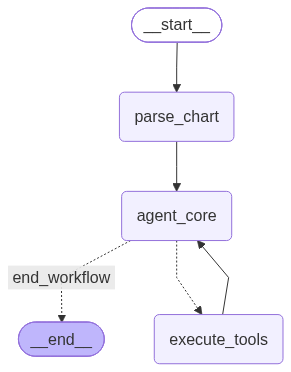

In [20]:
summary_agent

In [21]:
from langchain_core.messages import HumanMessage

def run_agent_test(test_name: str, input_type: str, file_path: str = None, user_query: str = None):
    """
    LangGraph Summary Agent ko testing scenarios ke sath debug aur run karne ka wrapper function.
    """
    print(f"\n{'='*15} 🚀 RUNNING TEST: {test_name.upper()} {'='*15}")
    
    # 1. User Message context build karna
    default_text = f"Please provide a summary for this {input_type}."
    final_query_text = user_query if user_query else default_text
    
    # 2. Initial state setup jise LangGraph dynamic node processing me access karega
    initial_state = {
        "messages": [HumanMessage(content=final_query_text)],
        "chart_context": ""  # Yeh variable 'parse_chart' node update karega
    }
    
    # 3. Custom payload handle karna agar chart file di gayi ho
    # (Aap is state context ko handle karne ke liye apne 'parse_chart_node' ko update kar sakte hain)
    if file_path:
        initial_state["file_path_input"] = file_path 
        print(f"📁 Target Document/Chart detected: {file_path}")

    print(f"💬 User Prompt sent to Agent: '{final_query_text}'\n")
    print("--- 🔄 Graph Node Execution Steps ---")
    
    # 4. LangGraph Stream running to keep track of active node processes
    final_state = None
    for output in summary_agent.stream(initial_state):
        for node_name, node_output in output.items():
            print(f"✅ Finished executing Node: [{node_name}]")
            # Tool calls ya execution tracking logs dekhne ke liye debugging logs:
            if "messages" in node_output and node_output["messages"]:
                last_msg = node_output["messages"][-1]
                if hasattr(last_msg, 'tool_calls') and last_msg.tool_calls:
                    print(f"   🛠️ Agent invoked a DB tool: {last_msg.tool_calls[0]['name']}")
                    print(f"   📝 Generated SQL: {last_msg.tool_calls[0]['args'].get('query_string', '')}")
        final_state = output

    print("\n" + "="*50)
    print("📊 FINAL AGENT OUTPUT (Executive Summary):")
    print("="*50)
    
    # Final message stream syntax se message display print format
    if final_state:
        # LangGraph ke output dict se state data fetch karna
        last_node = list(final_state.keys())[-1]
        state_messages = final_state[last_node].get("messages", [])
        if state_messages:
            print(state_messages[-1].content)
        else:
            print("No output message captured. Check agent_core node configuration.")
    print(f"{'='*50}\n")


In [23]:
run_agent_test(
    test_name="Chart Data Summary",
    input_type="chart",
    file_path="charts/pie_chart.png"
)



=============== 🚀 RUNNING TEST: CHART DATA SUMMARY ===============
📁 Target Document/Chart detected: charts/pie_chart.png
💬 User Prompt sent to Agent: 'Please provide a summary for this chart.'

--- 🔄 Graph Node Execution Steps ---
🤖 [Gemini] Parsing chart details...
✅ Finished executing Node: [parse_chart]
⚡ [Groq] Deciding next steps or compiling final summary...
✅ Finished executing Node: [agent_core]

📊 FINAL AGENT OUTPUT (Executive Summary):
I’m happy to create a concise summary, but I don’t have the chart data or a description of the visual you’re referring to. Could you please provide the chart image, its title, or any key details (e.g., metrics, time range, filters, or the type of visualization) so I can generate an accurate summary for you?



In [ ]:
# from litellm import completion

# res = completion(
#     model="groq/openai/gpt-oss-120b",
#     messages=[{"role": "user", "content": "Say hello"}]
# )
# print(res.choices[0].message.content)

Hello! 👋


In [ ]:
run_agent_test(
    test_name="Chart Data Summary",
    input_type="chart",
    file_path="heat_map.png.jpg"
)


In [ ]:
run_agent_test(
    test_name="Chart Context + Construction Safety Tool Lookup",
    input_type="chart",
    file_path="timeline.png",
    user_query="Compare the timeline trend visible in this chart with the safety incidents logged in the construction_ai database."
)
